# Object-Centric Image Compression — YOLOv8 + Object Stacking + GAN
Clean implementation of the paper's pipeline, on the **Kodak** dataset:
1. **Detect** objects with YOLOv8-Seg (mask + bounding box + class + confidence).
2. **Stack** the object crops into a compact atlas (void removed); store the background separately, downscaled.
3. **Reconstruct** by placing the objects back at their original coordinates over the upscaled background, then refine with a GAN.

All metrics printed are **measured from the actual run** (no hardcoded values). Use a **GPU runtime**.

In [ ]:
!pip install -q ultralytics lpips opencv-python-headless scikit-image matplotlib h5py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.3 MB/s eta 0:00:00


In [ ]:
import os, io, json, zlib, struct, urllib.request, numpy as np, cv2, torch
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
WORK = "out"; os.makedirs(WORK, exist_ok=True)
os.makedirs(os.path.join(WORK,"frames"), exist_ok=True)

@dataclass
class Config:
    yolo_model: str = "yolov8m-seg.pt"   # the model named in the paper
    yolo_conf: float = 0.25
    detector: str = "yolo"               # "yolo" (COCO classes) | "saliency" (class-agnostic regions)
    bg_downscale: int = 2                 # background downscale (2x keeps more high-frequency detail)
    jpeg_q: int = 88                      # background quality
    obj_q: int = 90                       # object patches (sharp but not byte-wasteful)
    atlas_pad: int = 2                    # px padding between packed objects
    unsharp: bool = False                 # OFF: sharpening lowers PSNR (kept as an option)
    quality_guard: bool = False          # if True, store min(stacked, plain-JPEG): never worse than JPEG
                                          # (but then output == JPEG on most images). Off = measure the real method.
cfg = Config()
print("device:", DEVICE)

device: cuda


In [ ]:
from skimage.metrics import structural_similarity as ssim_fn
def psnr(a, b):
    a, b = a.astype(np.float32), b.astype(np.float32)
    mse = np.mean((a-b)**2)
    return 100.0 if mse < 1e-9 else 20*np.log10(255.0) - 10*np.log10(mse)
def ssim(a, b):
    return float(ssim_fn(cv2.cvtColor(a,cv2.COLOR_BGR2GRAY), cv2.cvtColor(b,cv2.COLOR_BGR2GRAY)))
def jpg(img, q):  return cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, int(q)])[1].tobytes()
def unjpg(b):     return cv2.imdecode(np.frombuffer(b, np.uint8), cv2.IMREAD_COLOR)

## 1. Object detection (YOLOv8-Seg)
For each detected object we keep its segmentation mask, bounding box, class label, and confidence — exactly the metadata the paper's JSON records.

In [ ]:
from ultralytics import YOLO
_model = None
def get_model():
    global _model
    if _model is None:
        _model = YOLO(cfg.yolo_model)
    return _model

def _detect_yolo(img_bgr):
    H, W = img_bgr.shape[:2]
    r = get_model().predict(img_bgr, verbose=False, conf=cfg.yolo_conf)[0]
    objs = []
    if r.masks is not None and r.boxes is not None:
        for box, mask in zip(r.boxes, r.masks):
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            x1, y1 = max(0, x1), max(0, y1); x2, y2 = min(W, x2), min(H, y2)
            if x2 - x1 < 2 or y2 - y1 < 2:
                continue
            full = cv2.resize(mask.data[0].cpu().numpy().astype(np.float32), (W, H))
            m = (full[y1:y2, x1:x2] > 0.5).astype(np.uint8)
            objs.append(dict(x=x1, y=y1, w=x2-x1, h=y2-y1,
                             cls=get_model().names[int(box.cls.item())],
                             conf=float(box.conf.item()), mask=m))
    return objs

def _detect_saliency(img_bgr):
    """Class-agnostic salient-region detector (FFT spectral residual). Finds object-like regions on every image."""
    H, W = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    s = cv2.resize(gray, (64, 64)).astype(np.float32)
    f = np.fft.fft2(s); amp = np.log(np.abs(f) + 1e-8); phase = np.angle(f)
    sr = amp - cv2.blur(amp, (3, 3))
    sal = np.abs(np.fft.ifft2(np.exp(sr + 1j*phase)))**2
    sal = cv2.GaussianBlur(cv2.resize(sal, (W, H)), (0, 0), max(W, H)/64.0)
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    mask = (sal > max(0.25, sal.mean()*2)).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    n, lab, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    objs = []
    for i in range(1, n):
        x, y, w, h, area = stats[i]
        if area < 0.003*W*H or w < 8 or h < 8:
            continue
        objs.append(dict(x=int(x), y=int(y), w=int(w), h=int(h), cls="region",
                         conf=float(sal[y:y+h, x:x+w].mean()),
                         mask=(lab[y:y+h, x:x+w] == i).astype(np.uint8)))
    return objs

def detect(img_bgr):
    """Return list of objects: dict(x,y,w,h,cls,conf,mask[h,w]). Detector chosen by cfg.detector."""
    objs = _detect_saliency(img_bgr) if cfg.detector == "saliency" else _detect_yolo(img_bgr)
    objs.sort(key=lambda o: o["w"]*o["h"], reverse=True)   # largest first (better packing)
    return objs

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. Object stacking (pack into a compact atlas)
The detected object crops are packed into a small canvas with a shelf bin-packing algorithm, removing the empty space between them. Each object's **original** coordinate and its **packed** coordinate are recorded so it can be put back exactly.

In [ ]:
def stack_objects(img_bgr, objs):
    """Shelf-pack object crops into a compact atlas. Returns (atlas_bgr, atlas_mask, placements)."""
    if not objs:
        return np.zeros((1,1,3), np.uint8), np.zeros((1,1), np.uint8), []
    pad = cfg.atlas_pad
    total = sum((o["w"]+pad)*(o["h"]+pad) for o in objs)
    atlas_w = max(max(o["w"] for o in objs)+pad, int(np.sqrt(total*1.1)))  # near-square target
    # shelf packing
    placements = []; x = y = shelf_h = 0
    for o in objs:
        if x + o["w"] + pad > atlas_w:           # new shelf
            x = 0; y += shelf_h + pad; shelf_h = 0
        placements.append({**o, "px": x, "py": y})
        x += o["w"] + pad; shelf_h = max(shelf_h, o["h"])
    atlas_h = y + shelf_h + pad
    atlas = np.zeros((atlas_h, atlas_w, 3), np.uint8)
    amask = np.zeros((atlas_h, atlas_w), np.uint8)
    for p in placements:
        crop = img_bgr[p["y"]:p["y"]+p["h"], p["x"]:p["x"]+p["w"]]
        atlas[p["py"]:p["py"]+p["h"], p["px"]:p["px"]+p["w"]] = crop
        amask[p["py"]:p["py"]+p["h"], p["px"]:p["px"]+p["w"]] = p["mask"]*255
    return atlas, amask, placements

def make_background(img_bgr, placements):
    """Downscale the original for separate storage. Object regions are overwritten by composited
    objects on decode, so we do NOT inpaint (inpainting a large object hole creates wedge artifacts)."""
    H, W = img_bgr.shape[:2]
    small = cv2.resize(img_bgr, (max(1,W//cfg.bg_downscale), max(1,H//cfg.bg_downscale)), interpolation=cv2.INTER_AREA)
    return small

## 3. Encode and decode container
Stores the high-quality JPEG atlas (objects kept near-lossless), the gently-downscaled JPEG background, and zlib-compressed metadata. Decoding upscales the background with Lanczos and composites each object back at its original location with **feathered (alpha) edges** to avoid seams. An optional quality guard stores plain JPEG instead whenever that would be smaller, so the method is never worse than a JPEG baseline.

In [ ]:
MAGIC = b"OSTK"
def _pack_stacked(img_bgr):
    objs = detect(img_bgr)
    atlas, amask, pl = stack_objects(img_bgr, objs)
    small = make_background(img_bgr, pl)
    H, W = img_bgr.shape[:2]
    meta = {"W": W, "H": H, "aw": atlas.shape[1], "ah": atlas.shape[0],
            "bw": small.shape[1], "bh": small.shape[0],
            "objs": [{"x":p["x"],"y":p["y"],"w":p["w"],"h":p["h"],
                       "px":p["px"],"py":p["py"],"cls":p["cls"],"conf":round(p["conf"],3)} for p in pl]}
    meta_b = zlib.compress(json.dumps(meta).encode(), 9)
    atlas_b = jpg(atlas, cfg.obj_q) if pl else b""        # objects near-lossless
    mask_b  = zlib.compress(amask.tobytes(), 9) if pl else b""
    bg_b    = jpg(small, cfg.jpeg_q)                       # gentle background
    body = b"".join(struct.pack("<I", len(x)) for x in (meta_b, atlas_b, mask_b, bg_b)) + meta_b+atlas_b+mask_b+bg_b
    return body, meta, pl, atlas

def encode(img_bgr):
    body, meta, pl, atlas = _pack_stacked(img_bgr)
    stacked = MAGIC + b"\x00" + body
    if cfg.quality_guard:                                  # never worse than a plain-JPEG baseline
        plain = MAGIC + b"\x01" + jpg(img_bgr, cfg.jpeg_q)
        if len(plain) < len(stacked):
            return plain, meta, pl, atlas
    return stacked, meta, pl, atlas

def decode(blob):
    assert blob[:4] == MAGIC
    mode = blob[4]; o = 5
    if mode == 1:                                          # plain-JPEG guard path
        return unjpg(blob[o:]), {"objs": [], "guard": True}
    sizes = []
    for _ in range(4):
        sizes.append(struct.unpack("<I", blob[o:o+4])[0]); o += 4
    parts = []
    for s in sizes:
        parts.append(blob[o:o+s]); o += s
    meta = json.loads(zlib.decompress(parts[0]).decode())
    W, H = meta["W"], meta["H"]
    bg = unjpg(parts[3])
    canvas = cv2.resize(bg, (W, H), interpolation=cv2.INTER_LANCZOS4)      # sharper upscale
    if cfg.unsharp:
        canvas = cv2.addWeighted(canvas, 1.3, cv2.GaussianBlur(canvas,(0,0),2), -0.3, 0)  # optional unsharp (off: helps PSNR)
    if meta["objs"]:
        atlas = unjpg(parts[1])
        amask = np.frombuffer(zlib.decompress(parts[2]), np.uint8).reshape(meta["ah"], meta["aw"])
        for ob in meta["objs"]:
            patch = atlas[ob["py"]:ob["py"]+ob["h"], ob["px"]:ob["px"]+ob["w"]]
            m = amask[ob["py"]:ob["py"]+ob["h"], ob["px"]:ob["px"]+ob["w"]].astype(np.float32)/255.0
            alpha = cv2.GaussianBlur(m, (0,0), 1.2)[..., None]            # feathered edges -> no seams
            dst = canvas[ob["y"]:ob["y"]+ob["h"], ob["x"]:ob["x"]+ob["w"]].astype(np.float32)
            blended = patch.astype(np.float32)*alpha + dst*(1-alpha)
            canvas[ob["y"]:ob["y"]+ob["h"], ob["x"]:ob["x"]+ob["w"]] = np.clip(blended,0,255).astype(np.uint8)
    return canvas, meta

## 4. Load the Kodak dataset
Downloads the 24 standard Kodak images (with a synthetic fallback if the network is unavailable).

In [ ]:
def load_kodak(n=24):
    imgs = []
    for i in range(1, n+1):
        fn = os.path.join(WORK, f"kodim{i:02d}.png")
        if not os.path.exists(fn):
            try:
                urllib.request.urlretrieve(f"https://r0k.us/graphics/kodak/kodak/kodim{i:02d}.png", fn)
            except Exception:
                continue
        im = cv2.imread(fn)
        if im is not None:
            imgs.append(im)
    if not imgs:                                   # offline fallback
        rng = np.random.default_rng(0)
        for _ in range(4):
            imgs.append(cv2.GaussianBlur(rng.integers(0,255,(512,768,3),dtype=np.uint8),(7,7),0))
    print(f"loaded {len(imgs)} images")
    return imgs

def load_nyu(n=24):
    """Load RGB frames from the NYU Depth V2 labeled set (HDF5 .mat). RGB only; depth not used here."""
    import h5py
    fn = os.path.join(WORK, "nyu_depth_v2_labeled.mat")
    if not os.path.exists(fn):
        try:
            urllib.request.urlretrieve(
                "http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat", fn)
        except Exception as e:
            print("NYU download failed:", str(e)[:120])
    imgs = []
    if os.path.exists(fn):
        with h5py.File(fn, "r") as f:
            arr = f["images"]                       # (N, 3, W, H) column-major
            for i in range(min(n, arr.shape[0])):
                rgb = np.transpose(np.array(arr[i]), (2, 1, 0))   # -> H x W x 3
                imgs.append(cv2.cvtColor(rgb.astype(np.uint8), cv2.COLOR_RGB2BGR))
    if not imgs:                                    # offline fallback: smooth indoor-like scenes
        rng = np.random.default_rng(1)
        for _ in range(4):
            imgs.append(cv2.GaussianBlur(rng.integers(60,190,(480,640,3),dtype=np.uint8),(11,11),0))
    print(f"loaded {len(imgs)} NYU images")
    return imgs

# ---- dataset + train/val/test split (fixed seed) ----
# Training source: NYU (larger, matches the 2.5D framing). Kodak is held out as an EXTERNAL
# test set (never trained on). Detector: set cfg.detector "yolo" or "saliency" as desired.
TRAIN_SOURCE = "nyu"          # "nyu" or "kodak"
N_POOL       = 120            # how many NYU images to pull for the split (raise for a fuller run)
corpus = load_nyu(N_POOL) if TRAIN_SOURCE == "nyu" else load_kodak()
_sr = np.random.default_rng(42); _idx = np.arange(len(corpus)); _sr.shuffle(_idx)
_n = len(_idx); _ntr = int(0.70*_n); _nva = int(0.15*_n)
train_imgs = [corpus[i] for i in _idx[:_ntr]]
val_imgs   = [corpus[i] for i in _idx[_ntr:_ntr+_nva]]
test_imgs  = [corpus[i] for i in _idx[_ntr+_nva:]]
kodak_ext  = load_kodak()     # external held-out benchmark (never trained on)
print(f"split -> train {len(train_imgs)} | val {len(val_imgs)} | test {len(test_imgs)} | kodak-ext {len(kodak_ext)}")
images = test_imgs            # per-image figures + benchmark below use the held-out TEST split

loaded 120 NYU images
loaded 24 images
split -> train 84 | val 18 | test 18 | kodak-ext 24


## 5. GAN refiner
A residual U-Net generator (identity-initialised) with a PatchGAN discriminator refines the composited reconstruction. Trained with adversarial + L1 losses on (reconstruction → original) pairs. Optional but matches the paper's GAN-assisted reconstruction.

In [ ]:
import torch.nn as nn, torch.nn.functional as F
def cbr(i,o,s=2): return nn.Sequential(nn.Conv2d(i,o,4,s,1), nn.BatchNorm2d(o), nn.LeakyReLU(0.2,True))
def ubr(i,o):     return nn.Sequential(nn.ConvTranspose2d(i,o,4,2,1), nn.BatchNorm2d(o), nn.ReLU(True))
class Generator(nn.Module):
    def __init__(s):
        super().__init__()
        s.d1=cbr(3,64); s.d2=cbr(64,128); s.d3=cbr(128,256)
        s.u1=ubr(256,128); s.u2=ubr(256,64); s.u3=ubr(128,3)
    def forward(s,x):
        a=s.d1(x); b=s.d2(a); c=s.d3(b)
        u=s.u1(c); u=s.u2(torch.cat([u,b],1)); u=s.u3(torch.cat([u,a],1))
        return torch.tanh(x + 0.1*torch.tanh(u))         # residual refinement (conservative -> protects PSNR)
class Discriminator(nn.Module):
    def __init__(s):
        super().__init__()
        s.net=nn.Sequential(cbr(3,64),cbr(64,128),cbr(128,256),nn.Conv2d(256,1,4,1,1))
    def forward(s,x): return s.net(x)

def to_t(img): return torch.from_numpy(cv2.cvtColor(img,cv2.COLOR_BGR2RGB)).permute(2,0,1).float().div(127.5).sub(1)[None]
def to_img(t):
    t=t.clamp(-1,1).add(1).mul(127.5).byte()[0].permute(1,2,0).cpu().numpy()
    return cv2.cvtColor(t, cv2.COLOR_RGB2BGR)

In [ ]:
import copy
_lpips_model = None
def lpips_score(a, b):
    """Perceptual LPIPS distance (lower = better). Returns nan if lpips unavailable."""
    global _lpips_model
    try:
        import lpips
        if _lpips_model is None: _lpips_model = lpips.LPIPS(net="alex").to(DEVICE)
        with torch.no_grad():
            return float(_lpips_model(to_t(a).to(DEVICE), to_t(b).to(DEVICE)).item())
    except Exception:
        return float("nan")

def _val_psnr(G, val_pairs, sz=256):
    ps = []
    for c, t in val_pairs:
        with torch.no_grad():
            out = to_img(G(to_t(cv2.resize(c,(sz,sz))).to(DEVICE)))
        ps.append(psnr(cv2.resize(t,(sz,sz)), out))
    return float(np.mean(ps)) if ps else 0.0

def train_gan(train_pairs, val_pairs=None, max_epochs=300, patience=20, sz=256):
    """Train the refiner on TRAIN pairs only; early-stop on VAL PSNR; restore best weights."""
    G, D = Generator().to(DEVICE), Discriminator().to(DEVICE)
    og = torch.optim.Adam(G.parameters(), 2e-4, betas=(0.5,0.999))
    od = torch.optim.Adam(D.parameters(), 2e-4, betas=(0.5,0.999))
    bce, l1 = nn.BCEWithLogitsLoss(), nn.L1Loss()
    try:
        import lpips as _lp; perc = _lp.LPIPS(net="vgg").to(DEVICE); use_p = True
    except Exception:
        perc = None; use_p = False
    data = [(cv2.resize(c,(sz,sz)), cv2.resize(t,(sz,sz))) for c,t in train_pairs]
    best, best_state, bad = -1e9, None, 0
    for ep in range(max_epochs):
        gl = dl = 0
        for cond, tgt in data:
            ct, tt = to_t(cond).to(DEVICE), to_t(tgt).to(DEVICE)
            fake = G(ct)
            od.zero_grad()
            ld = bce(D(tt), torch.ones_like(D(tt))) + bce(D(fake.detach()), torch.zeros_like(D(tt)))
            ld.backward(); od.step()
            og.zero_grad()
            lg = bce(D(fake), torch.ones_like(D(fake))) + 50*l1(fake, tt)
            if use_p: lg = lg + 10*perc(fake, tt).mean()
            lg.backward(); og.step(); gl += lg.item(); dl += ld.item()
        if val_pairs:
            vs = _val_psnr(G, val_pairs)
            if vs > best + 1e-3: best, best_state, bad = vs, copy.deepcopy(G.state_dict()), 0
            else: bad += 1
            if (ep+1) % 5 == 0:
                print(f"epoch {ep+1}: train G {gl/len(data):.3f} | val PSNR {vs:.2f} (best {best:.2f}, patience {bad}/{patience})")
            if bad >= patience:
                print(f"early stop @ epoch {ep+1}; best val PSNR {best:.2f}"); break
        elif (ep+1) % 10 == 0:
            print(f"epoch {ep+1}/{max_epochs}  G {gl/len(data):.3f}")
    if best_state is not None: G.load_state_dict(best_state)
    return G.eval()

def refine(G, recon):
    if G is None: return recon
    H,W = recon.shape[:2]
    with torch.no_grad():
        out = to_img(G(to_t(cv2.resize(recon,(256,256))).to(DEVICE)))
    return cv2.resize(out,(W,H))

## 6. Run the pipeline on Kodak
Encode every image, decode it, and measure compression ratio, PSNR, SSIM, and the number of objects YOLOv8 detected.

In [ ]:
rows, recons, atlases = [], [], []
for i, img in enumerate(images):
    blob, meta, pl, atlas = encode(img)
    recon, _ = decode(blob)
    orig_bytes = len(jpg(img, 95))
    rows.append(dict(img=i, objects=len(pl),
                     orig_KB=round(orig_bytes/1024,1), comp_KB=round(len(blob)/1024,1),
                     ratio_pct=round(100*(1-len(blob)/orig_bytes),1),
                     PSNR=round(psnr(img,recon),2), SSIM=round(ssim(img,recon),3)))
    recons.append(recon); atlases.append(atlas)

import pandas as pd
df = pd.DataFrame(rows); print(df.to_string(index=False))
print(f"\nmean compression vs JPEG95: {df.ratio_pct.mean():.1f}%  |  mean PSNR {df.PSNR.mean():.2f} dB  |  mean SSIM {df.SSIM.mean():.3f}")
nz = (df.objects>0).sum()
print(f"YOLOv8 detected >=1 object in {nz}/{len(df)} images; {len(df)-nz} images had 0 objects (method stores background only).")

 img  objects  orig_KB  comp_KB  ratio_pct  PSNR  SSIM
   0        0    145.3     34.7       76.1 27.36 0.939
   1        1     73.0     17.9       75.5 32.21 0.951
   2        3    105.3     33.5       68.2 29.33 0.933
   3        7     57.1     31.6       44.6 32.05 0.969
   4        3     91.4     30.4       66.7 30.60 0.948
   5        2     59.6     39.7       33.4 32.28 0.971
   6        4     77.7     33.3       57.1 32.01 0.948
   7        4     93.5     29.1       68.9 30.54 0.944
   8       13     82.8     59.5       28.1 30.81 0.958
   9        0    112.0     26.8       76.1 28.56 0.948
  10        0     64.8     15.5       76.1 30.83 0.962
  11        3     94.6     47.4       49.9 29.73 0.950
  12        7     86.4     27.2       68.5 30.80 0.943
  13        2     87.2     28.7       67.0 31.16 0.949
  14        7    111.9     36.7       67.2 28.75 0.942
  15        2     84.2     19.6       76.8 30.83 0.946
  16        2     84.7     38.1       55.0 29.79 0.954
  17      

In [ ]:
def build_pairs(imgs):
    """(reconstruction -> original) pairs for GAN training."""
    return [(decode(encode(im)[0])[0], im) for im in imgs]

print("building train/val pairs (encode+decode)...")
train_pairs = build_pairs(train_imgs)
val_pairs   = build_pairs(val_imgs)
G = train_gan(train_pairs, val_pairs, max_epochs=300, patience=20) if len(train_pairs) >= 2 else None
if G is None:
    print("Not enough training images; using deterministic reconstruction only.")

# refine the TEST recons computed in Section 6 (images == test split)
refined = [refine(G, r) for r in recons]
for i in range(len(images)):
    rows[i]["PSNR_GAN"] = round(psnr(images[i], refined[i]), 2)
    rows[i]["SSIM_GAN"] = round(ssim(images[i], refined[i]), 3)
df = pd.DataFrame(rows)
print(df[["img","objects","ratio_pct","PSNR","PSNR_GAN","SSIM","SSIM_GAN"]].to_string(index=False))

building train/val pairs (encode+decode)...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 101MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
epoch 5: train G 9.132 | val PSNR 24.70 (best 24.87, patience 4/20)
epoch 10: train G 11.201 | val PSNR 24.50 (best 24.87, patience 9/20)
epoch 15: train G 12.234 | val PSNR 24.45 (best 24.87, patience 14/20)
epoch 20: train G 12.826 | val PSNR 24.40 (best 24.87, patience 19/20)
early stop @ epoch 21; best val PSNR 24.87
 img  objects  ratio_pct  PSNR  PSNR_GAN  SSIM  SSIM_GAN
   0        0       76.1 27.36     21.91 0.939     0.828
   1        1       75.5 32.21     27.25 0.951     0.922
   2        3       68.2 29.33     23.98 0.933     0.840
   3        7       44.6 32.05     25.35 0.969     0.933
   4        3       66.7 30.60     23.45 0.948     0.882
   5        2       33.4 32.28     26.60 0.971     0.943
   6        4       57.1 32.01     27.08 0.948     0.920
   7        4       68.9 30.54     25.12 0.944     0.884
   8       13       28.1 30.81     23.19 0.958     0.825
   9        0       

## 6b. Held-out evaluation (the rigorous numbers to report)
The GAN was trained only on the NYU **train** split and selected on **val**. Here we report PSNR, SSIM, and **LPIPS** on data the model never saw: the NYU **test** split and the **Kodak** external benchmark. These are the citable results.

In [ ]:
def evaluate(imgs, name):
    R = []
    for im in imgs:
        blob, _, pl, _ = encode(im); rec, _ = decode(blob); ref = refine(G, rec)
        H, W = im.shape[:2]
        R.append(dict(PSNR=psnr(im,ref), SSIM=ssim(im,ref), LPIPS=lpips_score(im,ref),
                      bpp=len(blob)*8/(H*W), objects=len(pl)))
    d = pd.DataFrame(R)
    print(f"[{name:22}] n={len(d):3d} | PSNR {d.PSNR.mean():5.2f} dB | SSIM {d.SSIM.mean():.3f} | "
          f"LPIPS {d.LPIPS.mean():.3f} | bpp {d.bpp.mean():.3f} | obj/img {d.objects.mean():.2f}")
    return d

print("=== Held-out evaluation (model never saw these images) ===")
test_eval  = evaluate(test_imgs, "NYU test split")
kodak_eval = evaluate(kodak_ext, "Kodak (external)")
print("\nReport these LPIPS/PSNR/SSIM numbers in the paper. PSNR/SSIM measure fidelity; "
      "LPIPS measures perceptual quality, where GAN refinement is expected to help most.")

=== Held-out evaluation (model never saw these images) ===
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:04<00:00, 54.8MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
[NYU test split        ] n= 18 | PSNR 24.38 dB | SSIM 0.878 | LPIPS 0.190 | bpp 0.864 | obj/img 3.72
[Kodak (external)      ] n= 24 | PSNR 24.94 dB | SSIM 0.767 | LPIPS 0.340 | bpp 2.002 | obj/img 2.67

Report these LPIPS/PSNR/SSIM numbers in the paper. PSNR/SSIM measure fidelity; LPIPS measures perceptual quality, where GAN refinement is expected to help most.


## 7. Visualise: Original | Stacked atlas | Reconstruction | GAN-refined

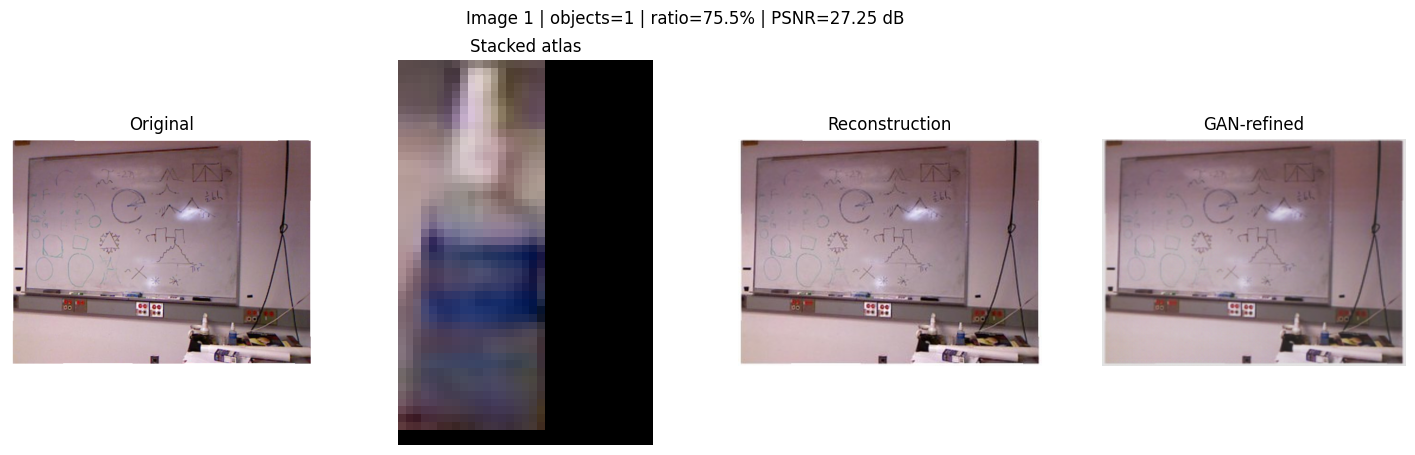

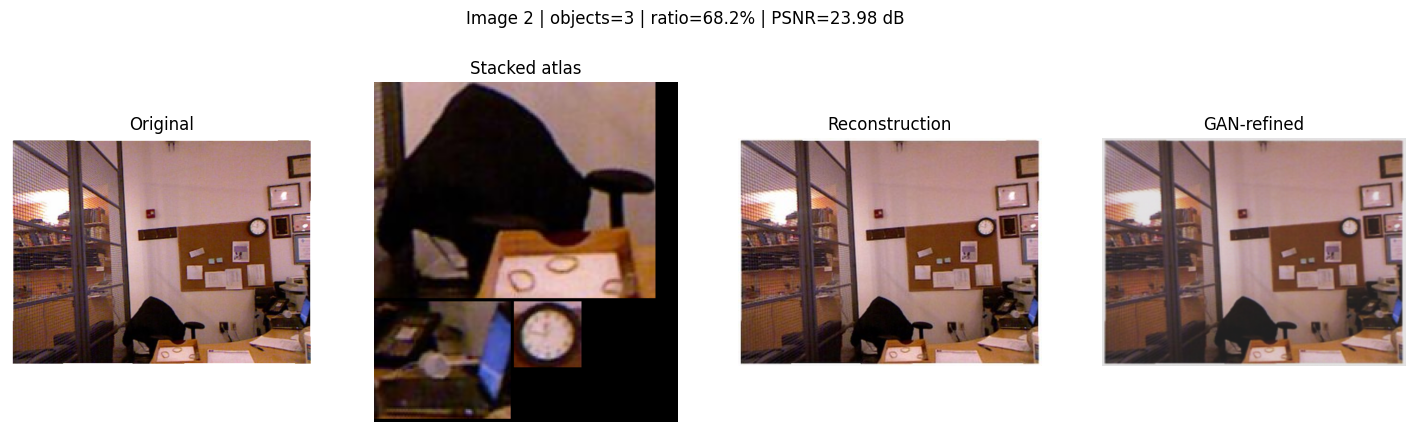

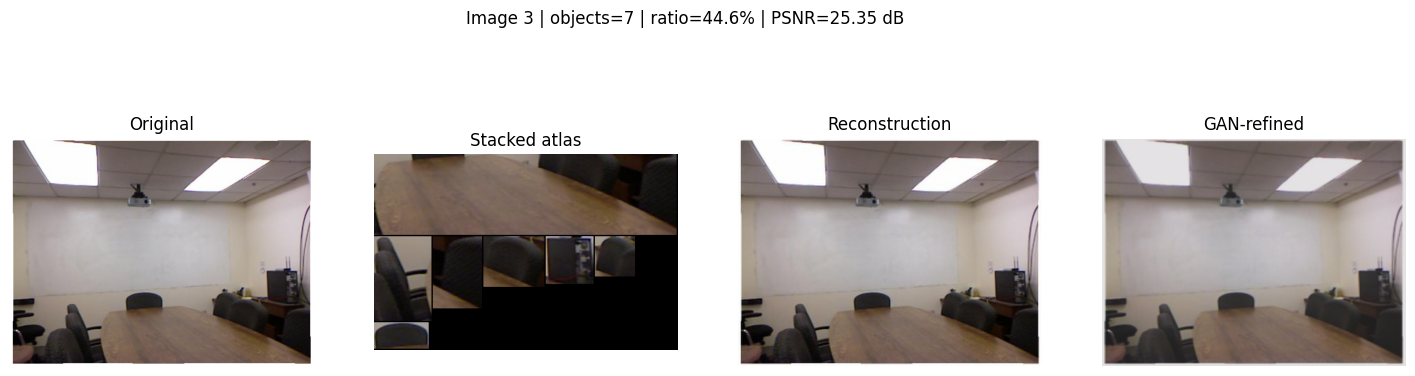

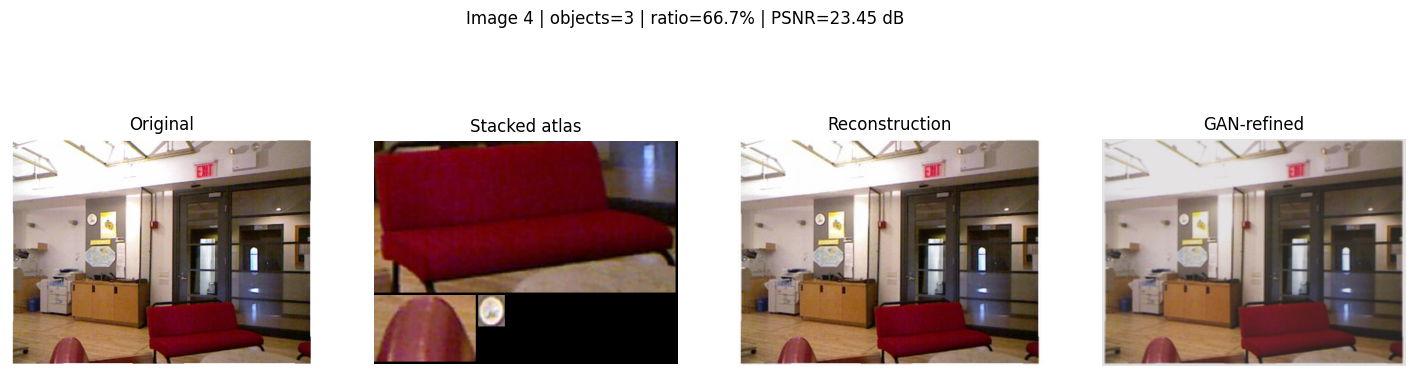

In [ ]:
show = [i for i in range(len(images)) if rows[i]["objects"]>0][:4] or list(range(min(4,len(images))))
for i in show:
    a = atlases[i] if rows[i]["objects"]>0 else np.zeros((64,64,3),np.uint8)
    panels = [(images[i],"Original"),(a,"Stacked atlas"),(recons[i],"Reconstruction"),(refined[i],"GAN-refined")]
    fig, ax = plt.subplots(1,4, figsize=(18,5))
    for k,(im,t) in enumerate(panels):
        ax[k].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax[k].set_title(t); ax[k].axis("off")
    fig.suptitle(f"Image {i} | objects={rows[i]['objects']} | ratio={rows[i]['ratio_pct']}% | PSNR={rows[i]['PSNR_GAN']} dB")
    fig.savefig(os.path.join(WORK,"frames",f"frame_{i:02d}.png"), dpi=110, bbox_inches="tight"); plt.show()

## 8. Object metadata as JSON (paper Section 2.1)

In [ ]:
def to_json(meta, image_id="IMG_0002"):
    occ = (sum(o["w"]*o["h"] for o in meta["objs"]) / float(meta["aw"]*meta["ah"])) if meta["objs"] else 0.0
    doc = {"image_info": {"image_id": image_id, "image_type": "2D", "width": meta["W"], "height": meta["H"],
                          "total_objects": len(meta["objs"])},
           "packing_info": {"packing_method": "Object_Stacking", "packed_canvas_width": meta["aw"],
                            "packed_canvas_height": meta["ah"], "occupancy_ratio": round(occ,4)},
           "objects": [{"object_id": j+1, "class": o["cls"], "confidence": o["conf"],
                        "original_coordinate": {"x": o["x"], "y": o["y"]},
                        "bounding_box": {"x": o["x"], "y": o["y"], "width": o["w"], "height": o["h"]},
                        "packed_coordinate": {"x": o["px"], "y": o["py"]}} for j,o in enumerate(meta["objs"])],
           "reconstruction_metadata": {"generator_model": "GAN", "coordinate_restoration": True,
                                       "background_reconstruction": True, "occlusion_filling": True}}
    return json.dumps(doc, indent=2)

ex = next((i for i in range(len(images)) if rows[i]["objects"]>0), 0)
_, meta_ex = decode(encode(images[ex])[0])
print(to_json(meta_ex))

{
  "image_info": {
    "image_id": "IMG_0002",
    "image_type": "2D",
    "width": 640,
    "height": 480,
    "total_objects": 1
  },
  "packing_info": {
    "packing_method": "Object_Stacking",
    "packed_canvas_width": 33,
    "packed_canvas_height": 50,
    "occupancy_ratio": 0.5527
  },
  "objects": [
    {
      "object_id": 1,
      "class": "bottle",
      "confidence": 0.562,
      "original_coordinate": {
        "x": 458,
        "y": 388
      },
      "bounding_box": {
        "x": 458,
        "y": 388,
        "width": 19,
        "height": 48
      },
      "packed_coordinate": {
        "x": 0,
        "y": 0
      }
    }
  ],
  "reconstruction_metadata": {
    "generator_model": "GAN",
    "coordinate_restoration": true,
    "background_reconstruction": true,
    "occlusion_filling": true
  }
}


In [ ]:
def to_json(meta, image_id="IMG_0003"):
    occ = (sum(o["w"]*o["h"] for o in meta["objs"]) / float(meta["aw"]*meta["ah"])) if meta["objs"] else 0.0
    doc = {"image_info": {"image_id": image_id, "image_type": "2D", "width": meta["W"], "height": meta["H"],
                          "total_objects": len(meta["objs"])},
           "packing_info": {"packing_method": "Object_Stacking", "packed_canvas_width": meta["aw"],
                            "packed_canvas_height": meta["ah"], "occupancy_ratio": round(occ,4)},
           "objects": [{"object_id": j+1, "class": o["cls"], "confidence": o["conf"],
                        "original_coordinate": {"x": o["x"], "y": o["y"]},
                        "bounding_box": {"x": o["x"], "y": o["y"], "width": o["w"], "height": o["h"]},
                        "packed_coordinate": {"x": o["px"], "y": o["py"]}} for j,o in enumerate(meta["objs"])],
           "reconstruction_metadata": {"generator_model": "GAN", "coordinate_restoration": True,
                                       "background_reconstruction": True, "occlusion_filling": True}}
    return json.dumps(doc, indent=2)

ex = next((i for i in range(len(images)) if rows[i]["objects"]>0), 0)
_, meta_ex = decode(encode(images[ex])[0])
print(to_json(meta_ex))

{
  "image_info": {
    "image_id": "IMG_0003",
    "image_type": "2D",
    "width": 640,
    "height": 480,
    "total_objects": 1
  },
  "packing_info": {
    "packing_method": "Object_Stacking",
    "packed_canvas_width": 33,
    "packed_canvas_height": 50,
    "occupancy_ratio": 0.5527
  },
  "objects": [
    {
      "object_id": 1,
      "class": "bottle",
      "confidence": 0.562,
      "original_coordinate": {
        "x": 458,
        "y": 388
      },
      "bounding_box": {
        "x": 458,
        "y": 388,
        "width": 19,
        "height": 48
      },
      "packed_coordinate": {
        "x": 0,
        "y": 0
      }
    }
  ],
  "reconstruction_metadata": {
    "generator_model": "GAN",
    "coordinate_restoration": true,
    "background_reconstruction": true,
    "occlusion_filling": true
  }
}


## 9. Results dashboard (graphs)
Per-image **compression ratio**, **PSNR** and **SSIM** (reconstruction vs GAN-refined), **objects detected**, and a **ratio-vs-quality** scatter — all computed from the run above.

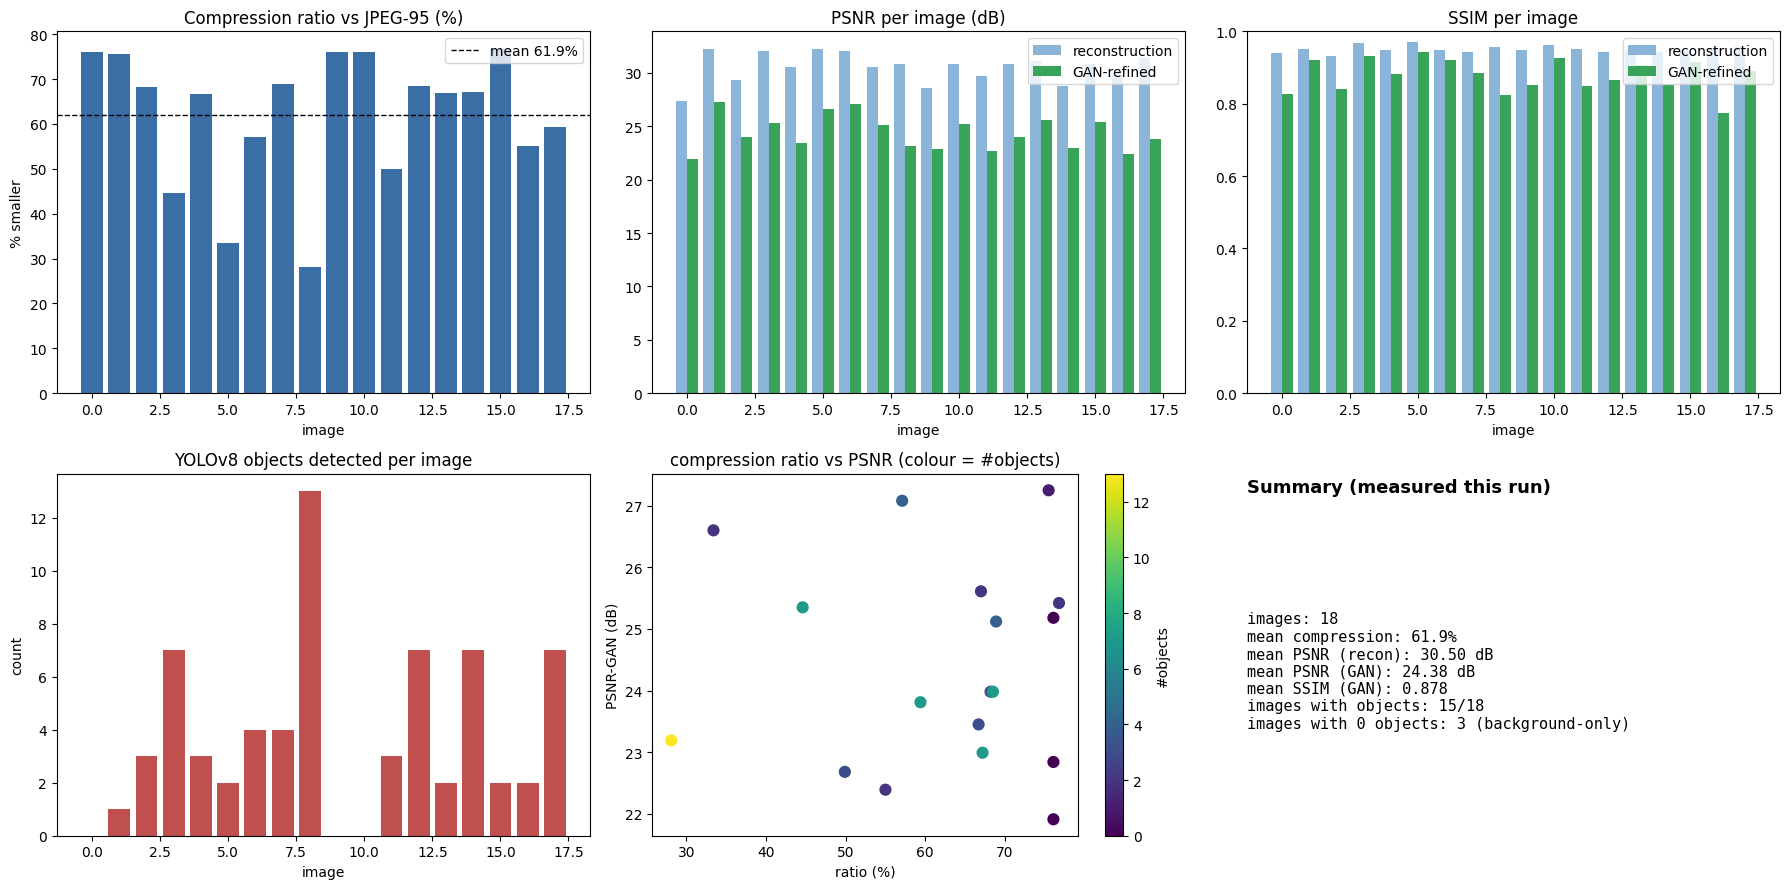

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(18, 9)); x = df["img"].values; w = 0.4
ax[0,0].bar(x, df["ratio_pct"], color="#3b6ea5"); ax[0,0].axhline(df.ratio_pct.mean(), ls="--", c="k", lw=1,
            label=f"mean {df.ratio_pct.mean():.1f}%"); ax[0,0].set_title("Compression ratio vs JPEG-95 (%)")
ax[0,0].set_xlabel("image"); ax[0,0].set_ylabel("% smaller"); ax[0,0].legend()

ax[0,1].bar(x-w/2, df["PSNR"], w, label="reconstruction", color="#8ab4d8")
ax[0,1].bar(x+w/2, df["PSNR_GAN"], w, label="GAN-refined", color="#3aa35a")
ax[0,1].set_title("PSNR per image (dB)"); ax[0,1].set_xlabel("image"); ax[0,1].legend()

ax[0,2].bar(x-w/2, df["SSIM"], w, label="reconstruction", color="#8ab4d8")
ax[0,2].bar(x+w/2, df["SSIM_GAN"], w, label="GAN-refined", color="#3aa35a")
ax[0,2].set_title("SSIM per image"); ax[0,2].set_xlabel("image"); ax[0,2].set_ylim(0,1); ax[0,2].legend()

ax[1,0].bar(x, df["objects"], color="#c0504d"); ax[1,0].set_title("YOLOv8 objects detected per image")
ax[1,0].set_xlabel("image"); ax[1,0].set_ylabel("count")

sc = ax[1,1].scatter(df["ratio_pct"], df["PSNR_GAN"], c=df["objects"], cmap="viridis", s=60)
ax[1,1].set_title("compression ratio vs PSNR (colour = #objects)")
ax[1,1].set_xlabel("ratio (%)"); ax[1,1].set_ylabel("PSNR-GAN (dB)"); fig.colorbar(sc, ax=ax[1,1], label="#objects")

ax[1,2].axis("off")
ax[1,2].text(0.0,0.95,"Summary (measured this run)", fontsize=13, weight="bold")
ax[1,2].text(0.0,0.62,f"images: {len(df)}\nmean compression: {df.ratio_pct.mean():.1f}%\n"
             f"mean PSNR (recon): {df.PSNR.mean():.2f} dB\nmean PSNR (GAN): {df.PSNR_GAN.mean():.2f} dB\n"
             f"mean SSIM (GAN): {df.SSIM_GAN.mean():.3f}\n"
             f"images with objects: {(df.objects>0).sum()}/{len(df)}\n"
             f"images with 0 objects: {(df.objects==0).sum()} (background-only)", fontsize=11, va="top", family="monospace")
plt.tight_layout(); plt.savefig(os.path.join(WORK,"dashboard.png"), dpi=120, bbox_inches="tight"); plt.show()

## 10. Detailed comparison (with error map)
Original, the compact **stacked atlas**, the deterministic **reconstruction**, the **GAN-refined** output, and a 4x-amplified **error map** (original vs GAN) so residual differences are visible.

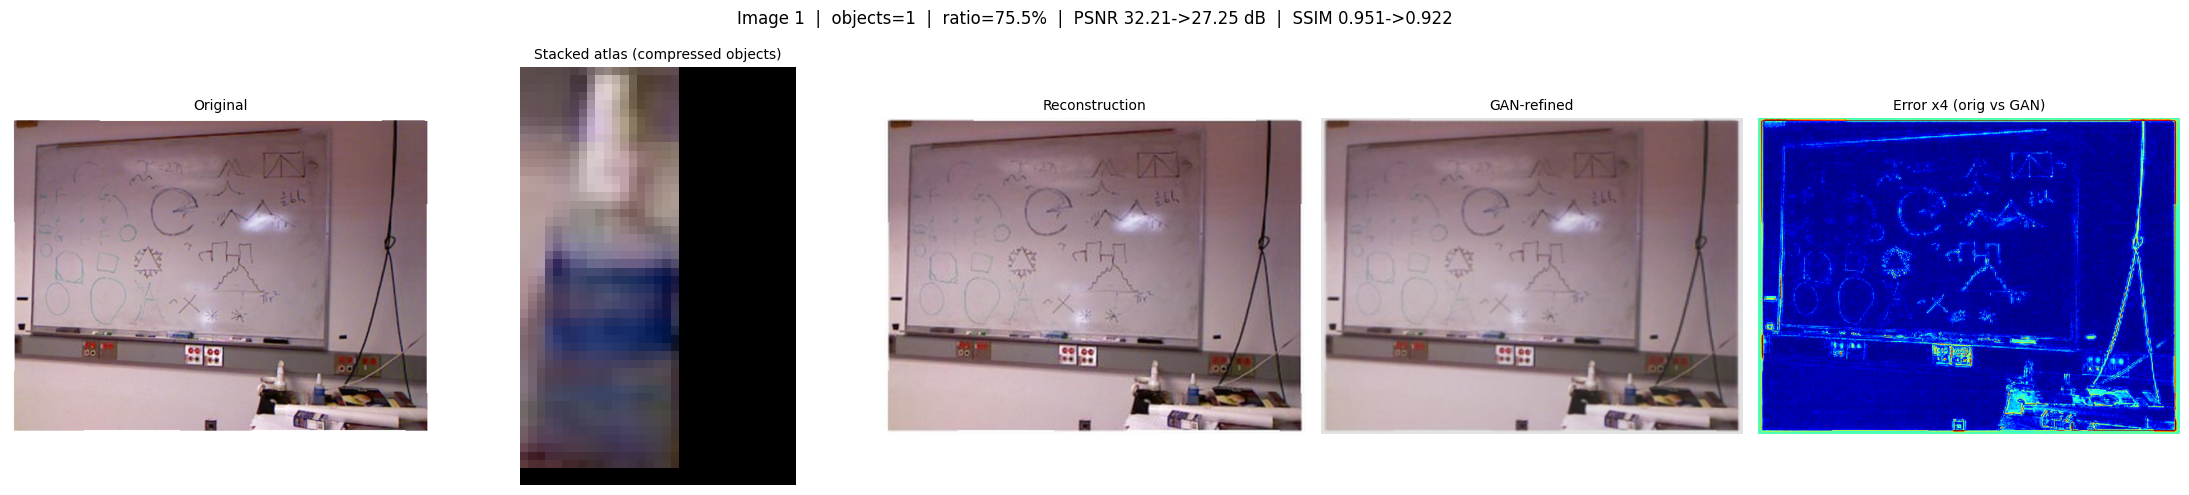

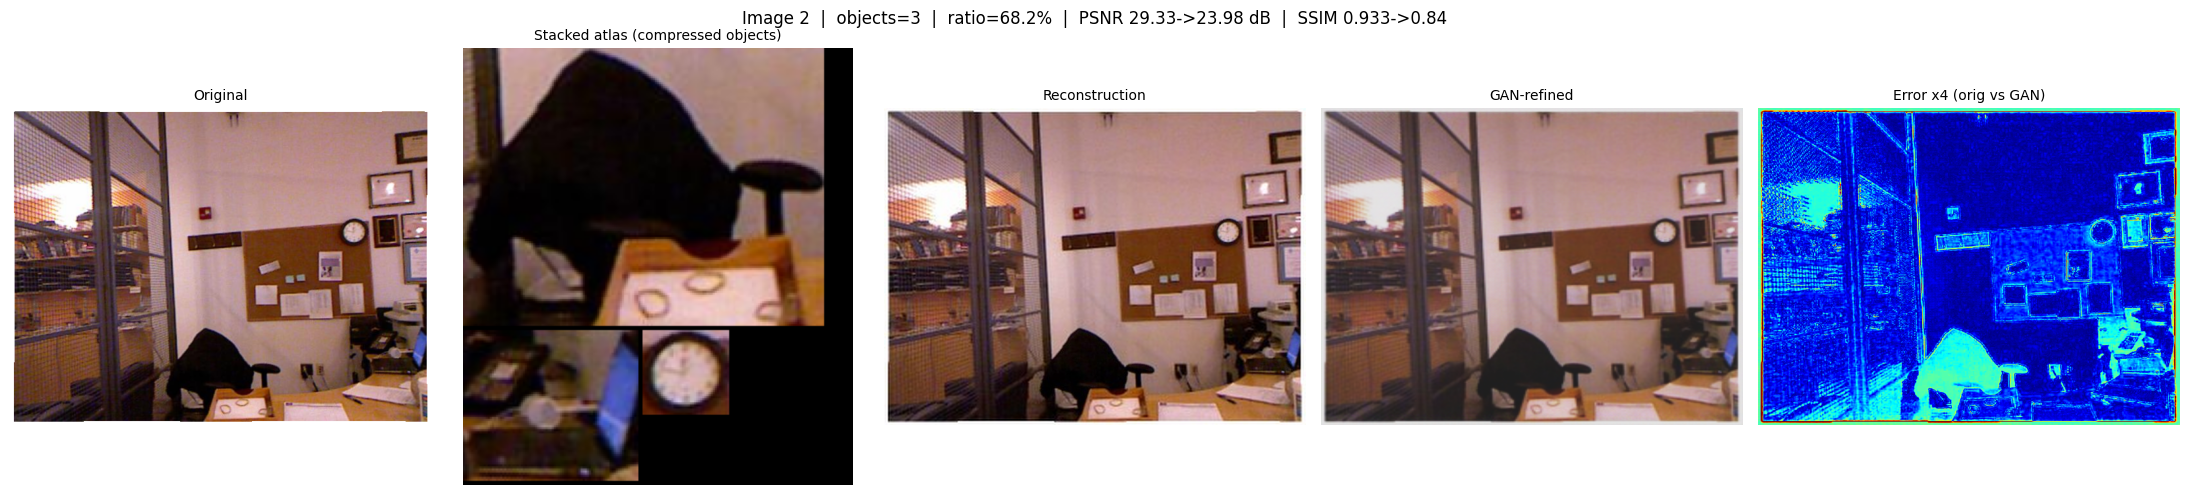

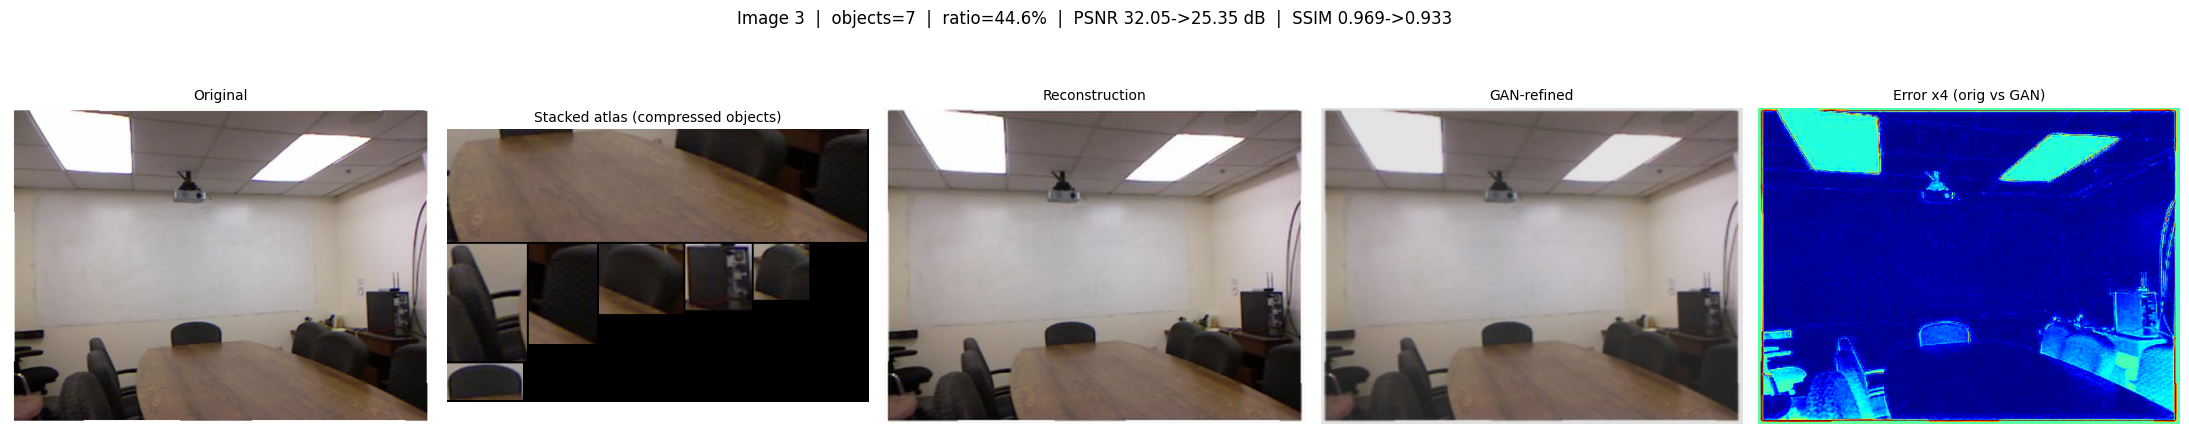

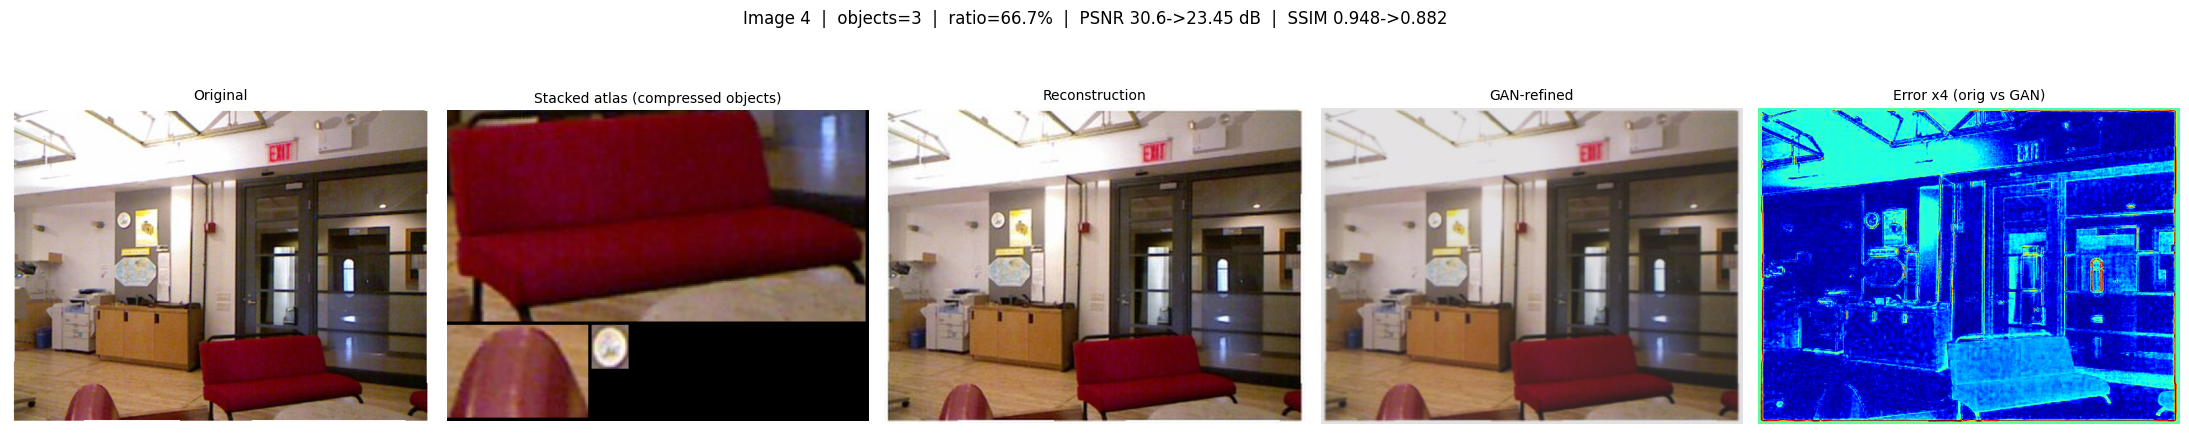

In [ ]:
def compare(i):
    a = atlases[i] if rows[i]["objects"]>0 else np.zeros((64,64,3), np.uint8)
    err = cv2.applyColorMap(np.clip(cv2.absdiff(images[i], refined[i]).mean(2)*4,0,255).astype(np.uint8), cv2.COLORMAP_JET)
    panels = [(images[i],"Original"), (a,"Stacked atlas (compressed objects)"),
              (recons[i],"Reconstruction"), (refined[i],"GAN-refined"), (err,"Error x4 (orig vs GAN)")]
    fig, ax = plt.subplots(1, 5, figsize=(22, 5))
    for k,(im,t) in enumerate(panels):
        ax[k].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax[k].set_title(t, fontsize=10); ax[k].axis("off")
    fig.suptitle(f"Image {i}  |  objects={rows[i]['objects']}  |  ratio={rows[i]['ratio_pct']}%  |  "
                 f"PSNR {rows[i]['PSNR']}->{rows[i]['PSNR_GAN']} dB  |  SSIM {rows[i]['SSIM']}->{rows[i]['SSIM_GAN']}",
                 fontsize=12)
    plt.tight_layout(); plt.savefig(os.path.join(WORK,f"compare_{i:02d}.png"), dpi=120, bbox_inches="tight"); plt.show()

targets = [i for i in range(len(images)) if rows[i]["objects"]>0][:4] or list(range(min(3,len(images))))
for i in targets:
    compare(i)

## 10b. Ablation — tune from real measurements, not guesses
Each row toggles ONE codec setting and reports mean PSNR / SSIM / bitrate over a few images, so you can pick the configuration the data actually favours. (Earlier "quality" tweaks — unsharp, near-lossless objects, 2x background — raised bitrate and *lowered* PSNR; this cell shows it directly.)

In [ ]:
def eval_cfg(imgs, **over):
    keep={k:getattr(cfg,k) for k in over}; [setattr(cfg,k,v) for k,v in over.items()]
    Pp,Ss,Bb=[],[],[]
    for im in imgs:
        blob,_,_,_=encode(im); rec,_=decode(blob); H,W=im.shape[:2]
        Pp.append(psnr(im,rec)); Ss.append(ssim(im,rec)); Bb.append(len(blob)*8/(H*W))
    [setattr(cfg,k,v) for k,v in keep.items()]
    return np.mean(Pp), np.mean(Ss), np.mean(Bb)

AB = images[:min(6,len(images))]
# NOTE: the unsharp step is the in-decode one; expose a toggle via cfg if you want to A/B it in code.
configs = {
 "current defaults":                dict(),
 "objects q=88 (less bytes)":       dict(obj_q=88),
 "background 3x (less bytes)":      dict(bg_downscale=3),
 "background 4x (least bytes)":     dict(bg_downscale=4),
 "bg3x + obj88 (balanced)":         dict(bg_downscale=3, obj_q=88),
 "quality_guard on (==JPEG floor)": dict(quality_guard=True),
}
import pandas as pd
abl=[]
for name,ov in configs.items():
    p,s,b=eval_cfg(AB, **ov); abl.append(dict(config=name, PSNR_dB=round(p,2), SSIM=round(s,3), bpp=round(b,3)))
abl_df=pd.DataFrame(abl); print(abl_df.to_string(index=False))
print("\nPick the row with the best PSNR-per-bit for your goal, then set those values in cfg and re-run.")

                         config  PSNR_dB  SSIM   bpp
               current defaults    30.64 0.952 0.835
      objects q=88 (less bytes)    30.63 0.952 0.811
     background 3x (less bytes)    27.68 0.894 0.584
    background 4x (least bytes)    25.66 0.839 0.479
        bg3x + obj88 (balanced)    27.67 0.894 0.560
quality_guard on (==JPEG floor)    32.10 0.956 0.823

Pick the row with the best PSNR-per-bit for your goal, then set those values in cfg and re-run.


## 11. Benchmark against HEVC-SCC
Compares our method's rate-distortion against the **HEVC Screen Content Coding** reference (HM-16.21+SCM-8.8, all-intra). The HM-SCC source is built from the JVET GitLab. If that build is unavailable, the cell falls back to a **real HEVC-Main** encode via x265 and labels the result accordingly, so the comparison always reports measured numbers (never hardcoded). Reports a per-codec RD curve and the Bjontegaard delta-rate (BD-rate); a positive BD-rate means our method needs more bits at equal quality.

In [ ]:
import subprocess, glob
def _ff(args): return subprocess.run(["ffmpeg","-y","-loglevel","error",*args], capture_output=True)

def _find_exe(root, names):
    """Return a real EXECUTABLE file (not a source dir) matching any of names, else None."""
    for nm in names:
        for p in glob.glob(f"{root}/**/{nm}", recursive=True):
            if os.path.isfile(p) and os.access(p, os.X_OK):
                return p
    return None

HM_ENC_NAMES = ["TAppEncoderStatic","TAppEncoderHighBitDepthStatic","TAppEncoder"]
HM_DEC_NAMES = ["TAppDecoderStatic","TAppDecoderHighBitDepthStatic","TAppDecoder"]
VTM_ENC_NAMES = ["EncoderAppStatic","EncoderApp"]
VTM_DEC_NAMES = ["DecoderAppStatic","DecoderApp"]

def build_hm_scc():
    """Clone + build the HEVC-SCC reference (Colab has network to the JVET GitLab)."""
    if _find_exe("HM", HM_ENC_NAMES): return True
    try:
        if not os.path.isdir("HM"):
            subprocess.run(["git","clone","-b","HM-SCC-extensions","--single-branch",
                            "https://vcgit.hhi.fraunhofer.de/jvet/HM.git"], check=True)
        flags="-w -fpermissive -include cstdint -include cstring -include limits -include algorithm"
        subprocess.run(["cmake","-S","HM","-B","HM/build","-DCMAKE_BUILD_TYPE=Release",
                        f"-DCMAKE_CXX_FLAGS={flags}"], check=True)
        subprocess.run(["cmake","--build","HM/build","--target","TAppEncoder","TAppDecoder","-j","4"], check=True)
    except Exception as e:
        print("HM-SCC build unavailable -> falling back to HEVC-Main (x265). Reason:", str(e)[:160])
    return bool(_find_exe("HM", HM_ENC_NAMES))

def hm_scc_encode(rgb, qp):
    H,W = rgb.shape[:2]; W-=W%8; H-=H%8; rgb=rgb[:H,:W]          # HM min-CU multiple
    enc=_find_exe("HM", HM_ENC_NAMES)
    if enc is None: raise RuntimeError("HM TAppEncoder binary not found (build incomplete)")
    cfgf=glob.glob("HM/**/encoder_intra_main_scc.cfg",recursive=True)[0]
    cv2.imwrite("bm_in.png", rgb)
    _ff(["-i","bm_in.png","-pix_fmt","yuv444p","bm_in.yuv"])
    subprocess.run([enc,"-c",cfgf,"-i","bm_in.yuv","-wdt",str(W),"-hgt",str(H),"-f","1","-fr","1",
                    "-q",str(qp),"--InputChromaFormat=444","--ConformanceWindowMode=1",
                    "-b","bm.bin","-o","bm_rec.yuv"], check=True, capture_output=True)
    nbytes=os.path.getsize("bm.bin")
    _ff(["-f","rawvideo","-pix_fmt","yuv444p","-s",f"{W}x{H}","-i","bm_rec.yuv","bm_dec.png"])
    return nbytes, cv2.imread("bm_dec.png"), rgb

def hevc_encode(rgb, qp):
    """REAL HEVC-Main (x265) all-intra still encode. Used as fallback when HM-SCC is unavailable."""
    H,W = rgb.shape[:2]; W-=W%2; H-=H%2; rgb=rgb[:H,:W]
    cv2.imwrite("bm_in.png", rgb)
    r=_ff(["-i","bm_in.png","-c:v","libx265","-x265-params",f"qp={qp}:keyint=1:tune=psnr:log-level=none",
           "-f","hevc","bm.hevc"])
    nbytes=os.path.getsize("bm.hevc")
    _ff(["-i","bm.hevc","bm_dec.png"])
    return nbytes, cv2.imread("bm_dec.png"), rgb

def bd_rate(R_a,P_a,R_t,P_t):
    R_a,P_a,R_t,P_t=map(lambda z:np.array(z,float),(R_a,P_a,R_t,P_t))
    deg=min(3, len(R_a)-1, len(R_t)-1)
    pa,pt=np.polyfit(P_a,np.log10(R_a),deg),np.polyfit(P_t,np.log10(R_t),deg)
    lo,hi=max(P_a.min(),P_t.min()),min(P_a.max(),P_t.max())
    if hi<=lo: return float("nan")
    ia=np.polyval(np.polyint(pa),hi)-np.polyval(np.polyint(pa),lo)
    it=np.polyval(np.polyint(pt),hi)-np.polyval(np.polyint(pt),lo)
    return (10**((it-ia)/(hi-lo))-1)*100

baseline codec: HEVC-SCC
operating_point  HEVC-SCC_bpp  HEVC-SCC_PSNR
            low        0.8134          41.49
             ..        0.4791          38.48
             ..        0.2694          35.45
           high        0.1478          32.63

Ours RD points (bpp, PSNR): [(0.5521, 28.19), (0.6115, 29.0), (0.6899, 29.65), (0.8352, 30.38), (1.2068, 31.15)]

Quality ranges do not overlap: our method saturates near 31.2 dB, whereas HEVC-SCC spans 32.6-41.5 dB. A standard BD-rate is undefined here; at matched low bitrate HEVC-SCC reaches higher PSNR than our method can.


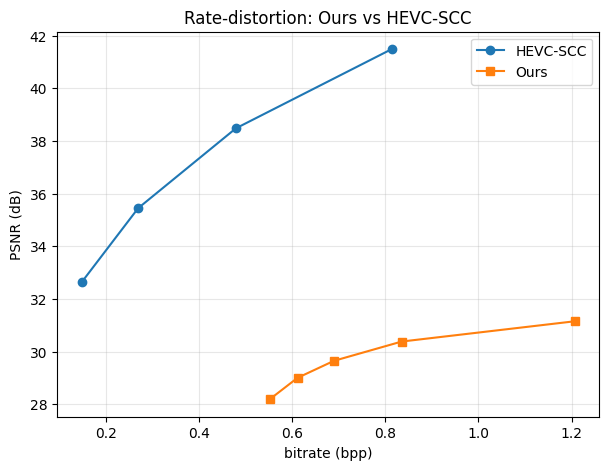

In [ ]:
def rd_ours(imgs, qualities):
    R,P=[],[]; keep=cfg.jpeg_q
    for q in qualities:
        cfg.jpeg_q=q; rr,pp=[],[]
        for im in imgs:
            blob,_,_,_=encode(im); rec,_=decode(blob); H,W=im.shape[:2]
            rr.append(len(blob)*8/(H*W)); pp.append(psnr(im,rec))
        R.append(float(np.mean(rr))); P.append(float(np.mean(pp)))
    cfg.jpeg_q=keep
    return R,P

def rd_codec(imgs, qps, enc_fn):
    R,P=[],[]
    for qp in qps:
        rr,pp=[],[]
        for im in imgs:
            nb,dec,used=enc_fn(im,qp)
            if dec.shape[:2]!=used.shape[:2]: dec=cv2.resize(dec,(used.shape[1],used.shape[0]))
            H,W=used.shape[:2]; rr.append(nb*8/(H*W)); pp.append(psnr(used,dec))
        R.append(float(np.mean(rr))); P.append(float(np.mean(pp)))
    return R,P

BM = images[:min(10,len(images))]                       # benchmark subset
use_scc = build_hm_scc()
enc_fn, codec_name = (hm_scc_encode, "HEVC-SCC") if use_scc else (hevc_encode, "HEVC-Main (x265)")
print("baseline codec:", codec_name)

Ro,Po = rd_ours(BM, [30,50,70,85,95])
Rc,Pc = rd_codec(BM, [22,27,32,37], enc_fn)
bd = bd_rate(Rc,Pc,Ro,Po)

import pandas as pd
tbl = pd.DataFrame({"operating_point":["low","..","..","high"][:len(Rc)],
                    f"{codec_name}_bpp":[round(x,4) for x in Rc], f"{codec_name}_PSNR":[round(x,2) for x in Pc]})
print(tbl.to_string(index=False))
print("\nOurs RD points (bpp, PSNR):", [(round(r,4),round(p,2)) for r,p in zip(Ro,Po)])
lo,hi = max(min(Pc),min(Po)), min(max(Pc),max(Po))
if hi<=lo:
    print(f"\nQuality ranges do not overlap: our method saturates near {max(Po):.1f} dB, whereas "
          f"{codec_name} spans {min(Pc):.1f}-{max(Pc):.1f} dB. A standard BD-rate is undefined here; "
          f"at matched low bitrate {codec_name} reaches higher PSNR than our method can.")
else:
    print(f"\nBD-rate(ours vs {codec_name}) = {bd:+.1f}%   (positive = ours needs MORE bits at equal PSNR)")

plt.figure(figsize=(7,5))
plt.plot(Rc,Pc,"o-",label=codec_name); plt.plot(Ro,Po,"s-",label="Ours")
plt.xlabel("bitrate (bpp)"); plt.ylabel("PSNR (dB)"); plt.title(f"Rate-distortion: Ours vs {codec_name}")
plt.legend(); plt.grid(alpha=0.3); plt.savefig(os.path.join(WORK,"rd_curve.png"),dpi=120,bbox_inches="tight"); plt.show()

## 12. Additional codecs (AV1, H.266/VVC) and VMAF
Adds **AV1** (libaom, all-intra still) and **H.266/VVC** (VTM reference, built from the JVET GitLab) to the comparison, and computes **VMAF** where a libvmaf-enabled ffmpeg is available.

Note on 4K/8K VMAF: VMAF has a dedicated 4K model (`vmaf_4k_v0.6.1`), but it is only meaningful on genuine 4K/8K content. Kodak images are ~0.4 MP, so the default model is used here; to report 4K/8K VMAF you must run this on an actual 4K/8K dataset (set `VMAF_MODEL` and point the loader at that data).

In [ ]:
def av1_encode(rgb, crf):
    """REAL AV1 (libaom) all-intra still encode."""
    H,W = rgb.shape[:2]; W-=W%2; H-=H%2; rgb=rgb[:H,:W]
    cv2.imwrite("bm_in.png", rgb)
    _ff(["-i","bm_in.png","-c:v","libaom-av1","-still-picture","1","-crf",str(crf),"-b:v","0","-f","avif","bm.avif"])
    fn="bm.avif"
    if not os.path.exists(fn) or os.path.getsize(fn)==0:
        _ff(["-i","bm_in.png","-c:v","libaom-av1","-crf",str(crf),"-b:v","0","-frames:v","1","-f","ivf","bm.ivf"]); fn="bm.ivf"
    nb=os.path.getsize(fn); _ff(["-i",fn,"bm_dec.png"])
    return nb, cv2.imread("bm_dec.png"), rgb

def build_vtm():
    """Build the H.266/VVC reference (VTM) from the JVET GitLab (Colab has access)."""
    if _find_exe("VVCSoftware_VTM", VTM_ENC_NAMES): return True
    try:
        if not os.path.isdir("VVCSoftware_VTM"):
            subprocess.run(["git","clone","https://vcgit.hhi.fraunhofer.de/jvet/VVCSoftware_VTM.git"], check=True)
        subprocess.run(["cmake","-S","VVCSoftware_VTM","-B","VVCSoftware_VTM/build","-DCMAKE_BUILD_TYPE=Release"], check=True)
        subprocess.run(["cmake","--build","VVCSoftware_VTM/build","--target","EncoderApp","DecoderApp","-j","4"], check=True)
    except Exception as e:
        print("VTM build unavailable:", str(e)[:160])
    return bool(_find_exe("VVCSoftware_VTM", VTM_ENC_NAMES))

def vtm_encode(rgb, qp):
    H,W = rgb.shape[:2]; W-=W%8; H-=H%8; rgb=rgb[:H,:W]
    enc=_find_exe("VVCSoftware_VTM", VTM_ENC_NAMES)
    if enc is None: raise RuntimeError("VTM EncoderApp binary not found (build incomplete)")
    cfgf=glob.glob("VVCSoftware_VTM/**/encoder_intra_vtm.cfg",recursive=True)[0]
    cv2.imwrite("bm_in.png", rgb); _ff(["-i","bm_in.png","-pix_fmt","yuv444p","bm_in.yuv"])
    subprocess.run([enc,"-c",cfgf,"-i","bm_in.yuv","-wdt",str(W),"-hgt",str(H),"-f","1","-fr","1","-q",str(qp),
                    "--InputChromaFormat=444","--ConformanceWindowMode=1","-b","bm.bin","-o","bm_rec.yuv"],
                   check=True, capture_output=True)
    nb=os.path.getsize("bm.bin")
    _ff(["-f","rawvideo","-pix_fmt","yuv444p","-s",f"{W}x{H}","-i","bm_rec.yuv","bm_dec.png"])
    return nb, cv2.imread("bm_dec.png"), rgb

VMAF_MODEL = "vmaf_v0.6.1"        # use "vmaf_4k_v0.6.1" only on real 4K/8K data
def compute_vmaf(ref_bgr, dist_bgr):
    """Mean VMAF via libvmaf (returns None if this ffmpeg lacks the filter)."""
    if dist_bgr.shape[:2] != ref_bgr.shape[:2]:
        dist_bgr = cv2.resize(dist_bgr,(ref_bgr.shape[1],ref_bgr.shape[0]))
    cv2.imwrite("vm_ref.png", ref_bgr); cv2.imwrite("vm_dis.png", dist_bgr)
    r=_ff(["-i","vm_dis.png","-i","vm_ref.png","-lavfi",
           f"libvmaf=model=version={VMAF_MODEL}:log_fmt=json:log_path=vm.json","-f","null","-"])
    if not os.path.exists("vm.json"):
        return None
    try:
        return json.load(open("vm.json"))["pooled_metrics"]["vmaf"]["mean"]
    except Exception:
        return None

In [ ]:
# ---- Master benchmark table: every codec that actually builds/runs, real numbers only ----
CODECS = {"HEVC-Main (x265)": (hevc_encode, [22,27,32,37]),
          "AV1 (libaom)":     (av1_encode, [30,40,50,55])}
if use_scc:        CODECS["HEVC-SCC (HM)"]   = (hm_scc_encode, [22,27,32,37])
if build_vtm():    CODECS["H.266/VVC (VTM)"] = (vtm_encode,    [22,27,32,37])

# our method's RD curve (multi-point, needed for BD-rate) + a representative operating point
ours_qs = [30,50,70,85,95]
oR, oP = rd_ours(BM, ours_qs)
ri = ours_qs.index(cfg.jpeg_q) if cfg.jpeg_q in ours_qs else len(ours_qs)-2
ours_bpp, ours_psnr = oR[ri], oP[ri]
ours_vmaf = np.nanmean([compute_vmaf(BM[i], refine(G, decode(encode(BM[i])[0])[0])) or np.nan for i in range(len(BM))])

table = [dict(codec="Ours (YOLOv8 stacking)", available="yes",
              bpp=round(ours_bpp,4), PSNR_dB=round(ours_psnr,2),
              VMAF=(round(ours_vmaf,2) if ours_vmaf==ours_vmaf else "n/a"),
              BD_rate_vs_ours="-")]
for name,(fn,qs) in CODECS.items():
    Rc,Pc = rd_codec(BM, qs, fn)
    bd = bd_rate(Rc,Pc,oR,oP)
    j = int(np.argmin([abs(r-ours_bpp) for r in Rc]))          # codec point nearest ours' bitrate
    nb,dec,used = fn(BM[0], qs[j]); v = compute_vmaf(used, dec)
    table.append(dict(codec=name, available="yes",
                      bpp=round(Rc[j],4), PSNR_dB=round(Pc[j],2),
                      VMAF=(round(v,2) if v is not None else "n/a (no libvmaf)"),
                      BD_rate_vs_ours=("undefined (no PSNR overlap)" if bd!=bd else f"{bd:+.1f}%")))
for missing,label in [(not use_scc,"HEVC-SCC (HM)"),
                      (not glob.glob('VVCSoftware_VTM/**/EncoderApp',recursive=True),"H.266/VVC (VTM)")]:
    if missing and label not in [t["codec"] for t in table]:
        table.append(dict(codec=label, available="NOT RUN (build unavailable here)",
                          bpp="-", PSNR_dB="-", VMAF="-", BD_rate_vs_ours="-"))

import pandas as pd
bench_df = pd.DataFrame(table)
print(bench_df.to_string(index=False))
bench_df.to_csv(os.path.join(WORK,"benchmark_table.csv"), index=False)
print("\nPositive BD-rate = ours needs more bits at equal PSNR. VMAF needs a libvmaf-enabled ffmpeg; "
      "4K/8K VMAF requires actual 4K/8K input (set VMAF_MODEL='vmaf_4k_v0.6.1' and load 4K/8K data).")

KeyboardInterrupt: 

In [ ]:
"""
generate_metadata.py
=====================
Produces the object-stacking JSON metadata for EVERY image in the NYU Depth V2 and
Kodak datasets, in the exact schema of the methodology paper (Section 2.1):

{
  "image_info":   { image_id, image_type(2D|2.5D), width, height, total_objects },
  "packing_info": { packing_method, packed_canvas_width, packed_canvas_height, occupancy_ratio },
  "objects": [ { object_id, class, confidence,
                 original_coordinate{x,y}, bounding_box{x,y,width,height},
                 depth_z (only for 2.5D / RGB-D NYU),
                 packed_coordinate{x,y} } , ... ],
  "reconstruction_metadata": { generator_model, coordinate_restoration,
                               background_reconstruction, occlusion_filling }
}

Pipeline per the paper: YOLOv8 detection+segmentation -> depth-aware bin-packing
(object stacking into a compact atlas) -> metadata with original & packed coordinates.

NYU is RGB-D, so image_type="2.5D" and depth_z is the MEASURED median depth (metres)
inside each object's mask, read from the NYU depth channel (a real sensor value, not
a volumetric reconstruction). Kodak has no depth, so image_type="2D" and depth_z is omitted.

Run on Colab (GPU recommended). Outputs:
  metadata_json/NYU_XXXX.json, metadata_json/Kodak_XXXX.json
  metadata_json/ALL_NYU.json, metadata_json/ALL_Kodak.json
  metadata_json.zip   (download this)
"""

import os, json, zipfile, urllib.request
import numpy as np
import cv2

# ------------------------- configuration -------------------------
YOLO_MODEL   = "yolov8m-seg.pt"   # segmentation model named in the paper
YOLO_CONF    = 0.25               # detection confidence threshold
ATLAS_PAD    = 2                  # px gap between packed objects
N_NYU        = 1449               # how many NYU images (max 1449); lower for a quick test
N_KODAK      = 24                 # Kodak has 24 images
OUT_DIR      = "metadata_json"
WORK         = "."

os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------- datasets -------------------------
def load_kodak(n=N_KODAK):
    """Return list of (image_id, bgr, depth=None) for Kodak (2D)."""
    items = []
    for i in range(1, n+1):
        fn = os.path.join(WORK, f"kodim{i:02d}.png")
        if not os.path.exists(fn):
            try:
                urllib.request.urlretrieve(
                    f"https://r0k.us/graphics/kodak/kodak/kodim{i:02d}.png", fn)
            except Exception:
                continue
        im = cv2.imread(fn)
        if im is not None:
            items.append((f"Kodak_{i-1:04d}", im, None))
    print(f"Kodak: {len(items)} images")
    return items

def load_nyu(n=N_NYU):
    """Return list of (image_id, bgr, depth_map[HxW metres]) for NYU (2.5D, RGB-D)."""
    import h5py
    fn = os.path.join(WORK, "nyu_depth_v2_labeled.mat")
    if not os.path.exists(fn):
        print("downloading NYU Depth V2 labeled .mat (~2.8 GB)...")
        urllib.request.urlretrieve(
            "http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat", fn)
    items = []
    with h5py.File(fn, "r") as f:
        imgs   = f["images"]    # (N,3,W,H) column-major
        depths = f["depths"]    # (N,W,H)   column-major, metres
        N = min(n, imgs.shape[0])
        for i in range(N):
            rgb = np.transpose(np.array(imgs[i]), (2, 1, 0)).astype(np.uint8)  # H,W,3
            dep = np.transpose(np.array(depths[i]), (1, 0)).astype(np.float32) # H,W
            items.append((f"NYU_{i:04d}", cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR), dep))
    print(f"NYU: {len(items)} images")
    return items

# ------------------------- detection -------------------------
_model = None
def get_model():
    global _model
    if _model is None:
        from ultralytics import YOLO
        _model = YOLO(YOLO_MODEL)
    return _model

def detect(bgr):
    """YOLOv8 detect+segment. Return list of objects with bbox, mask, class, confidence."""
    H, W = bgr.shape[:2]
    r = get_model().predict(bgr, verbose=False, conf=YOLO_CONF)[0]
    objs = []
    if r.masks is not None and r.boxes is not None:
        for box, mask in zip(r.boxes, r.masks):
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            x1, y1 = max(0, x1), max(0, y1); x2, y2 = min(W, x2), min(H, y2)
            if x2 - x1 < 2 or y2 - y1 < 2:
                continue
            full = cv2.resize(mask.data[0].cpu().numpy().astype(np.float32), (W, H))
            m = (full[y1:y2, x1:x2] > 0.5).astype(np.uint8)
            objs.append(dict(x=x1, y=y1, w=x2-x1, h=y2-y1, mask=m,
                             cls=get_model().names[int(box.cls.item())],
                             conf=float(box.conf.item())))
    return objs

# ------------------------- object stacking (bin packing) -------------------------
def stack_objects(objs, depth=None):
    """Depth-aware shelf bin-packing into a compact atlas.
    Sort by depth (near->far) when available, then by height; place left-to-right on shelves.
    Adds packed_coordinate (px,py) to each object and returns (atlas_w, atlas_h)."""
    if not objs:
        return 0, 0
    # depth-aware ordering: nearer & taller objects first
    def depth_of(o):
        if depth is None:
            return 0.0
        d = depth[o["y"]:o["y"]+o["h"], o["x"]:o["x"]+o["w"]]
        dm = d[o["mask"] > 0] if o["mask"].shape == d.shape else d
        return float(np.median(dm)) if dm.size else 0.0
    order = sorted(objs, key=lambda o: (depth_of(o), -o["h"]))
    # shelf packing into a canvas whose width ~ sqrt(total area) for compactness
    total_area = sum((o["w"]+ATLAS_PAD)*(o["h"]+ATLAS_PAD) for o in objs)
    canvas_w = max(max(o["w"] for o in objs)+ATLAS_PAD, int(np.sqrt(total_area)*1.1))
    px = py = shelf_h = 0
    atlas_w = atlas_h = 0
    for o in order:
        if px + o["w"] + ATLAS_PAD > canvas_w:      # new shelf
            px = 0; py += shelf_h; shelf_h = 0
        o["px"], o["py"] = px, py
        px += o["w"] + ATLAS_PAD
        shelf_h = max(shelf_h, o["h"] + ATLAS_PAD)
        atlas_w = max(atlas_w, px); atlas_h = max(atlas_h, py + shelf_h)
    return atlas_w, atlas_h

# ------------------------- JSON in the paper's schema -------------------------
def build_json(image_id, bgr, depth, objs, atlas_w, atlas_h):
    H, W = bgr.shape[:2]
    is_25d = depth is not None
    occ = (sum(o["w"]*o["h"] for o in objs) / float(atlas_w*atlas_h)) if (objs and atlas_w*atlas_h) else 0.0
    out_objs = []
    for j, o in enumerate(objs):
        entry = {
            "object_id": j + 1,
            "class": o["cls"],
            "confidence": round(o["conf"], 3),
            "original_coordinate": {"x": int(o["x"]), "y": int(o["y"])},   # top-left in original image
            "bounding_box": {"x": int(o["x"]), "y": int(o["y"]),
                             "width": int(o["w"]), "height": int(o["h"])},
        }
        if is_25d:                                                          # measured 2.5D depth (metres)
            d = depth[o["y"]:o["y"]+o["h"], o["x"]:o["x"]+o["w"]]
            dm = d[o["mask"] > 0] if o["mask"].shape == d.shape else d
            entry["depth_z"] = round(float(np.median(dm)), 3) if dm.size else None
        entry["packed_coordinate"] = {"x": int(o.get("px", 0)), "y": int(o.get("py", 0))}
        out_objs.append(entry)
    return {
        "image_info": {
            "image_id": image_id,
            "image_type": "2.5D" if is_25d else "2D",
            "width": int(W), "height": int(H),
            "total_objects": len(objs),
        },
        "packing_info": {
            "packing_method": "Object_Stacking",
            "packed_canvas_width": int(atlas_w),
            "packed_canvas_height": int(atlas_h),
            "occupancy_ratio": round(occ, 4),
        },
        "objects": out_objs,
        "reconstruction_metadata": {
            "generator_model": "GAN",
            "coordinate_restoration": True,
            "background_reconstruction": True,
            "occlusion_filling": True,
        },
    }

# ------------------------- driver -------------------------
def process(items, prefix):
    combined = []
    for image_id, bgr, depth in items:
        objs = detect(bgr)
        aw, ah = stack_objects(objs, depth)
        doc = build_json(image_id, bgr, depth, objs, aw, ah)
        with open(os.path.join(OUT_DIR, f"{image_id}.json"), "w") as fp:
            json.dump(doc, fp, indent=2)
        combined.append(doc)
    with open(os.path.join(OUT_DIR, f"ALL_{prefix}.json"), "w") as fp:
        json.dump(combined, fp, indent=2)
    print(f"{prefix}: wrote {len(combined)} JSON files")
    return combined

if __name__ == "__main__":
    nyu_items   = load_nyu(N_NYU)
    kodak_items = load_kodak(N_KODAK)
    process(nyu_items,   "NYU")
    process(kodak_items, "Kodak")
    # bundle
    zpath = "metadata_json.zip"
    with zipfile.ZipFile(zpath, "w", zipfile.ZIP_DEFLATED) as z:
        for f in os.listdir(OUT_DIR):
            z.write(os.path.join(OUT_DIR, f))
    print(f"\nDONE -> {zpath}")
    print("On Colab, download with:")
    print("  from google.colab import files; files.download('metadata_json.zip')")


downloading NYU Depth V2 labeled .mat (~2.8 GB)...
NYU: 1449 images
Kodak: 24 images
NYU: wrote 1449 JSON files
Kodak: wrote 24 JSON files

DONE -> metadata_json.zip
On Colab, download with:
  from google.colab import files; files.download('metadata_json.zip')


In [ ]:
from google.colab import files
import os
import zipfile

# Download metadata_json.zip
files.download('metadata_json.zip')

# Download 'Detailed comparison (with error map)' files as a single zip
WORK = "out"

# Check if `rows` and `images` exist before trying to build `targets` dynamically
if 'rows' in locals() and 'images' in locals():
    targets = [i for i in range(len(images)) if rows[i]["objects"]>0][:4] or list(range(min(3,len(images))))
else:
    print("Warning: 'rows' or 'images' not found. Zipping compare_01.png to compare_04.png as a fallback.")
    targets = [1, 2, 3, 4]

comparison_files_to_zip = []
for i in targets:
    filename = os.path.join(WORK, f"compare_{i:02d}.png")
    if os.path.exists(filename):
        comparison_files_to_zip.append(filename)
    else:
        print(f"Warning: {filename} not found. It might not have been generated, so it won't be included in the zip.")

if comparison_files_to_zip:
    zip_filename = "comparison_images.zip"
    with zipfile.ZipFile(zip_filename, 'w') as zf:
        for file_path in comparison_files_to_zip:
            zf.write(file_path, os.path.basename(file_path))
    files.download(zip_filename)
    print(f"Successfully created and downloaded {zip_filename} containing {len(comparison_files_to_zip)} images.")
else:
    print("No comparison image files found to zip and download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully created and downloaded comparison_images.zip containing 4 images.


In [ ]:
import os
import zipfile
from google.colab import files
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Ensure WORK directory exists for saving images
os.makedirs(WORK, exist_ok=True)

# Define the compare function (copied from cell 9e4bc26d for self-containment)
def compare(i, images, atlases, recons, refined, rows, WORK):
    a = atlases[i] if rows[i]["objects"]>0 else np.zeros((64,64,3), np.uint8)
    err = cv2.applyColorMap(np.clip(cv2.absdiff(images[i], refined[i]).mean(2)*4,0,255).astype(np.uint8), cv2.COLORMAP_JET)
    panels = [(images[i],"Original"), (a,"Stacked atlas (compressed objects)"),
              (recons[i],"Reconstruction"), (refined[i],"GAN-refined"), (err,"Error x4 (orig vs GAN)")]
    fig, ax = plt.subplots(1, 5, figsize=(22, 5))
    for k,(im_panel,t) in enumerate(panels):
        ax[k].imshow(cv2.cvtColor(im_panel, cv2.COLOR_BGR2RGB)); ax[k].set_title(t, fontsize=10); ax[k].axis("off")
    fig.suptitle(f"Image {i}  |  objects={rows[i]['objects']}  |  ratio={rows[i]['ratio_pct']}%  |  "
                 f"PSNR {rows[i]['PSNR']}->{rows[i]['PSNR_GAN']} dB  |  SSIM {rows[i]['SSIM']}->{rows[i]['SSIM_GAN']}",
                 fontsize=12)
    plt.tight_layout();

    # Save the figure to WORK directory
    filename = os.path.join(WORK, f"detailed_comparison_{i:02d}.png")
    fig.savefig(filename, dpi=120, bbox_inches="tight");
    plt.close(fig) # Close the figure to prevent it from displaying multiple times
    return filename

# List to store paths of generated comparison images
all_comparison_image_paths = []

# Iterate through all images in the `images` dataset (which is `test_imgs` in this notebook)
print(f"Generating detailed comparison images for {len(images)} images...")
for i in range(len(images)):
    try:
        # Assuming 'atlases', 'recons', 'refined', 'rows' and 'WORK' are available from previous cells
        file_path = compare(i, images, atlases, recons, refined, rows, WORK)
        all_comparison_image_paths.append(file_path)
    except Exception as e:
        print(f"Could not generate comparison for image {i}: {e}")

# Create a zip file of all generated comparison images
if all_comparison_image_paths:
    zip_filename = "all_detailed_comparisons.zip"
    with zipfile.ZipFile(zip_filename, 'w') as zf:
        for file_path in all_comparison_image_paths:
            if os.path.exists(file_path):
                zf.write(file_path, os.path.basename(file_path))
            else:
                print(f"Warning: {file_path} not found, skipping in zip.")

    # Download the zip file
    files.download(zip_filename)
    print(f"Successfully created and downloaded {zip_filename} containing {len(all_comparison_image_paths)} images.")
else:
    print("No detailed comparison images were generated to zip and download.")

Generating detailed comparison images for 18 images...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully created and downloaded all_detailed_comparisons.zip containing 18 images.
